<a href="https://colab.research.google.com/github/renegarcialuces/Analisis-de-Datos-Portafolio/blob/main/ED01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importar herramientas de analisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# **Carga de los datos**

In [5]:
# Cargar documentos para analisis desde la pc
from google.colab import files
uploaded = files.upload()

Saving telecom_users.csv to telecom_users.csv


# **Creación del DataFrame**

In [6]:
filename = 'telecom_users.csv'

In [7]:
df = pd.read_csv(filename, index_col=0) #[index_col= 0] Elimina la columna (Unnamed: 0).

# **Conociendo el datset**

In [8]:
# Qué columnas tiene el DataFrame?
df.columns

Index(['IDCliente', 'Genero', 'Aposentado', 'Casado', 'Dependentes',
       'MesesComoCliente', 'ServicoTelefone', 'MultiplasLinhas',
       'ServicoInternet', 'ServicoSegurancaOnline', 'ServicoBackupOnline',
       'ProtecaoEquipamento', 'ServicoSuporteTecnico', 'ServicoStreamingTV',
       'ServicoFilmes', 'TipoContrato', 'FaturaDigital', 'FormaPagamento',
       'ValorMensal', 'TotalGasto', 'Churn', 'Codigo'],
      dtype='object')

In [9]:
# De qué tamaños es el set de datos?
df.shape

(5986, 22)

In [11]:
# Tiene valores nulos o ausentes?
df.isna().sum()

,0
IDCliente,0
Genero,0
Aposentado,0
Casado,0
Dependentes,1
MesesComoCliente,0
ServicoTelefone,0
MultiplasLinhas,0
ServicoInternet,0
ServicoSegurancaOnline,0


In [19]:
# Typos de columnas?
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5974 entries, 1869 to 860
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   IDCliente               5974 non-null   category
 1   Genero                  5974 non-null   category
 2   Aposentado              5974 non-null   category
 3   Casado                  5974 non-null   category
 4   Dependentes             5974 non-null   category
 5   MesesComoCliente        5974 non-null   int64   
 6   ServicoTelefone         5974 non-null   category
 7   MultiplasLinhas         5974 non-null   category
 8   ServicoInternet         5974 non-null   category
 9   ServicoSegurancaOnline  5974 non-null   category
 10  ServicoBackupOnline     5974 non-null   category
 11  ProtecaoEquipamento     5974 non-null   category
 12  ServicoSuporteTecnico   5974 non-null   category
 13  ServicoStreamingTV      5974 non-null   category
 14  ServicoFilmes           597

In [13]:
# Distribución estadística de las columnas numericas
df.describe()

,Aposentado,MesesComoCliente,ValorMensal,Codigo
count,5986.000000,5986.000000,5986.000000,0.0
mean,0.161377,32.468760,64.802213,NaN
std,0.367909,24.516391,30.114702,NaN
min,0.000000,0.000000,18.250000,NaN
25%,0.000000,9.000000,35.650000,NaN
50%,0.000000,29.000000,70.400000,NaN
75%,0.000000,56.000000,89.900000,NaN
max,1.000000,72.000000,118.750000,NaN


In [14]:
# Distribución estadística de las columnas categóricas
df.describe(exclude=['int', 'float'])

,IDCliente,Genero,Casado,Dependentes,ServicoTelefone,MultiplasLinhas,ServicoInternet,ServicoSegurancaOnline,ServicoBackupOnline,ProtecaoEquipamento,ServicoSuporteTecnico,ServicoStreamingTV,ServicoFilmes,TipoContrato,FaturaDigital,FormaPagamento,TotalGasto,Churn
count,5986,5986,5986,5985,5986,5986,5986,5986,5986,5986,5986,5986,5986,5986,5986,5986,5986,5985
unique,5986,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,5611,2
top,4795-UXVCJ,Masculino,Nao,Nao,Sim,Nao,Fibra,Nao,Nao,Nao,Nao,Nao,Nao,Mensal,Sim,BoletoEletronico,,Nao
freq,1,3050,3082,4195,5396,2848,2627,2982,2605,2640,2960,2389,2356,3269,3528,2006,10,4398


# **Limpieza y preparación de datos**

In [15]:
# Ajuster tipo de categórico a numerico
df['TotalGasto'] = pd.to_numeric(df['TotalGasto'], errors='coerce')

# Covertir columnas numericas a string
df['Aposentado'] = df['Aposentado'].astype('category')

In [16]:
for col in df.columns:
  if df[col].dtypes == 'O':
    df[col] = df[col].astype('category')

In [17]:
# Borrando columnas vacia
df.dropna(axis=1, how='all', inplace=True)

In [18]:
# Borras datos faltantes
df.dropna(how='any', inplace=True)

# **Tablas de frecuencia y gráficos**




***** Genero *****




,Genero,n(i),f(i),N(i),F(i)
0,Masculino,3043,3043,50.937395,0.852651
1,Feminino,2931,5974,49.062605,0.821269


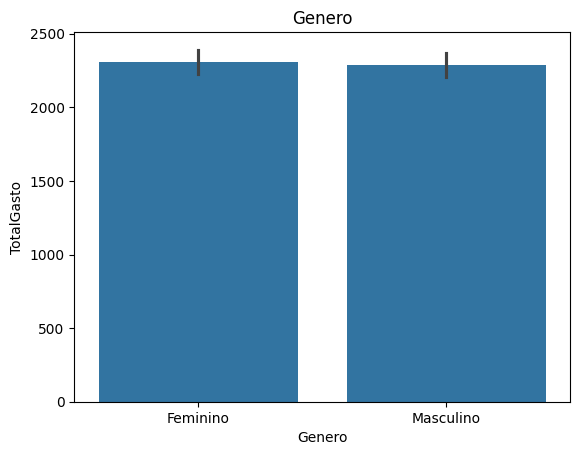




***** Aposentado *****




,Aposentado,n(i),f(i),N(i),F(i)
0,0,5008,5008,83.82993,1.403246
1,1,966,5974,16.17007,0.270674


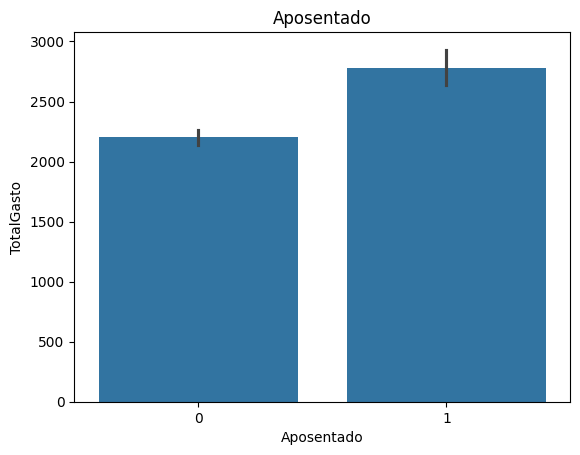




***** Casado *****




,Casado,n(i),f(i),N(i),F(i)
0,Nao,3080,3080,51.556746,0.863019
1,Sim,2894,5974,48.443254,0.810901


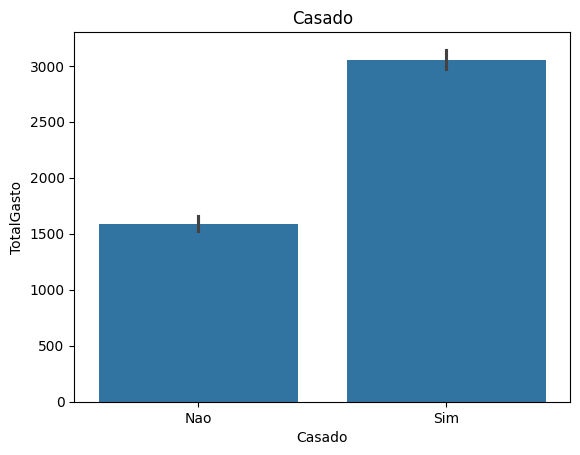




***** Dependentes *****




,Dependentes,n(i),f(i),N(i),F(i)
0,Nao,4194,4194,70.204218,1.175163
1,Sim,1780,5974,29.795782,0.498758


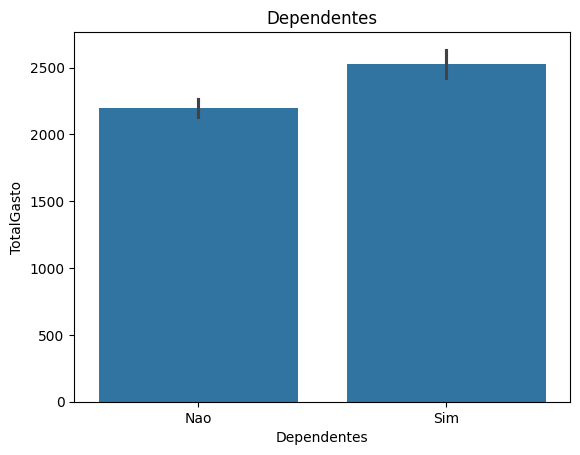




***** ServicoTelefone *****




,ServicoTelefone,n(i),f(i),N(i),F(i)
0,Sim,5386,5386,90.157349,1.509162
1,Nao,588,5974,9.842651,0.164758


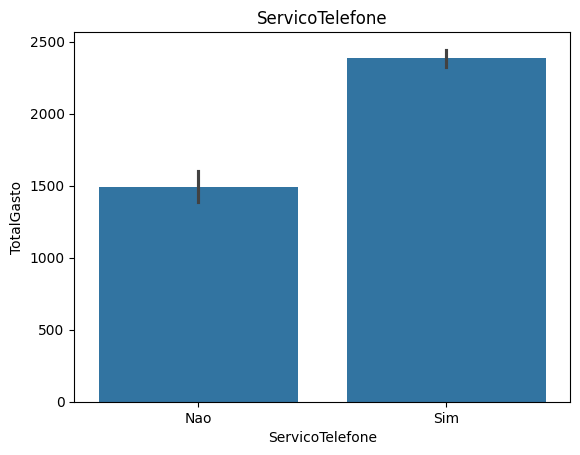




***** MultiplasLinhas *****




,MultiplasLinhas,n(i),f(i),N(i),F(i)
0,Nao,2842,2842,47.572816,0.796331
1,Sim,2544,5386,42.584533,0.712831
2,SemTelefone,588,5974,9.842651,0.164758


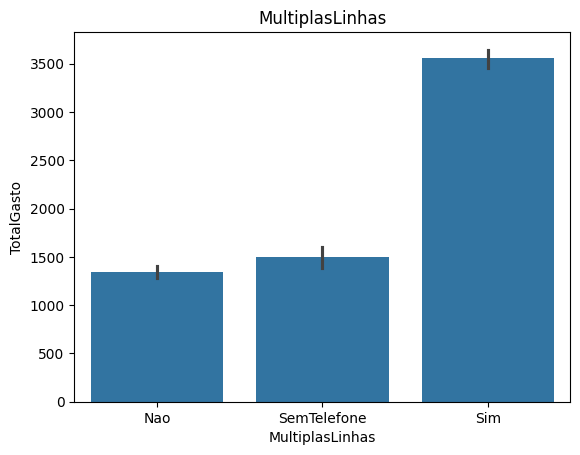




***** ServicoInternet *****




,ServicoInternet,n(i),f(i),N(i),F(i)
0,Fibra,2627,2627,43.973887,0.736088
1,DSL,2063,4690,34.532976,0.578055
2,Nao,1284,5974,21.493137,0.359778


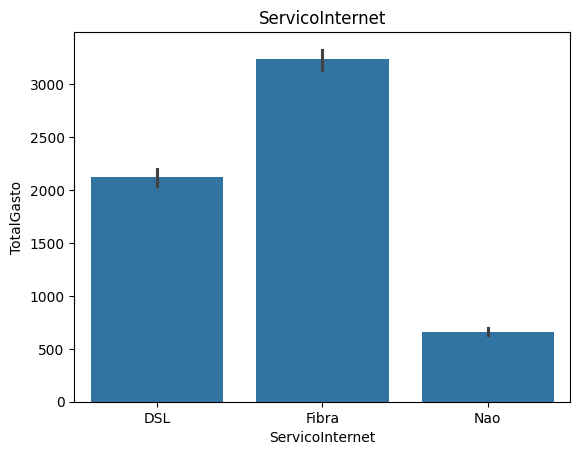




***** ServicoSegurancaOnline *****




,ServicoSegurancaOnline,n(i),f(i),N(i),F(i)
0,Nao,2982,2982,49.916304,0.835559
1,Sim,1708,4690,28.590559,0.478583
2,SemInternet,1284,5974,21.493137,0.359778


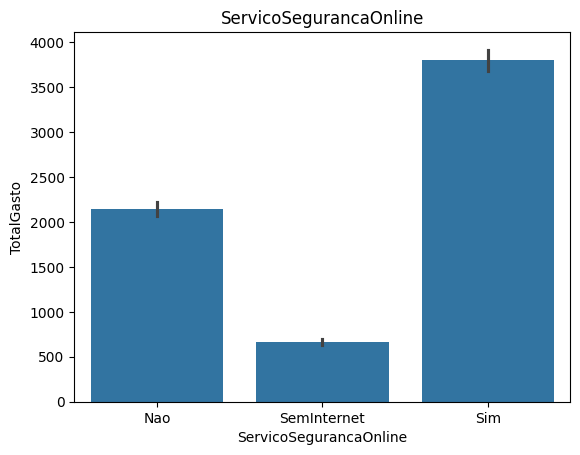




***** ServicoBackupOnline *****




,ServicoBackupOnline,n(i),f(i),N(i),F(i)
0,Nao,2604,2604,43.588885,0.729643
1,Sim,2086,4690,34.917978,0.584499
2,SemInternet,1284,5974,21.493137,0.359778


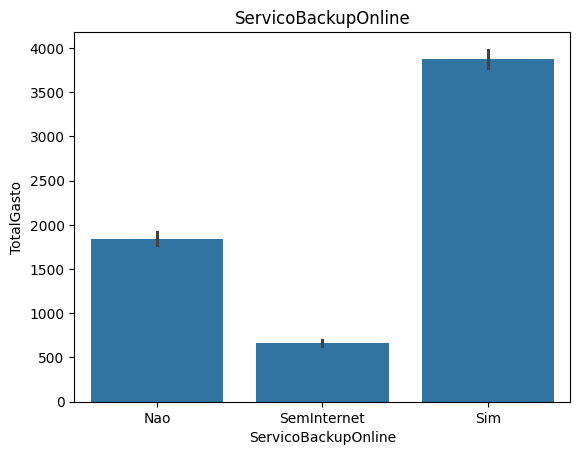




***** ProtecaoEquipamento *****




,ProtecaoEquipamento,n(i),f(i),N(i),F(i)
0,Nao,2639,2639,44.174757,0.739450
1,Sim,2051,4690,34.332106,0.574692
2,SemInternet,1284,5974,21.493137,0.359778


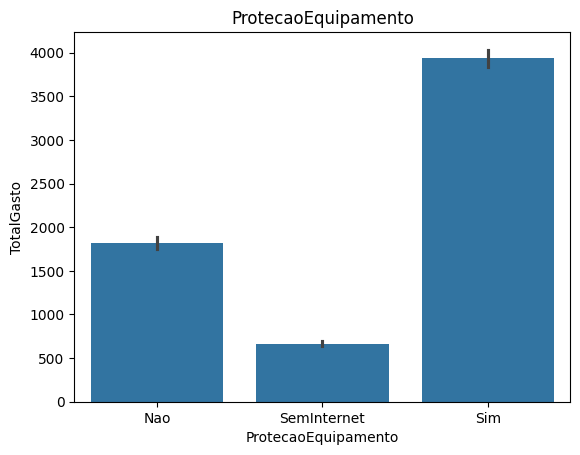




***** ServicoSuporteTecnico *****




,ServicoSuporteTecnico,n(i),f(i),N(i),F(i)
0,Nao,2959,2959,49.531302,0.829115
1,Sim,1731,4690,28.975561,0.485028
2,SemInternet,1284,5974,21.493137,0.359778


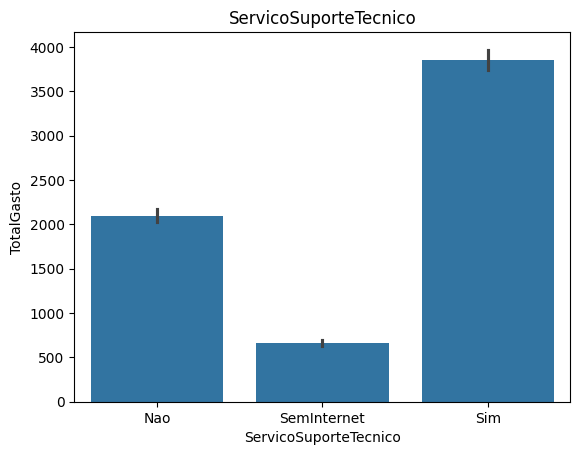




***** ServicoStreamingTV *****




,ServicoStreamingTV,n(i),f(i),N(i),F(i)
0,Nao,2388,2388,39.973217,0.669120
1,Sim,2302,4690,38.533646,0.645023
2,SemInternet,1284,5974,21.493137,0.359778


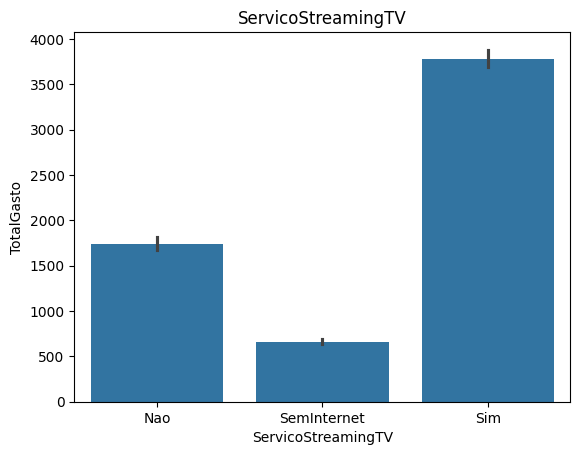




***** ServicoFilmes *****




,ServicoFilmes,n(i),f(i),N(i),F(i)
0,Nao,2353,2353,39.387345,0.659313
1,Sim,2337,4690,39.119518,0.654830
2,SemInternet,1284,5974,21.493137,0.359778


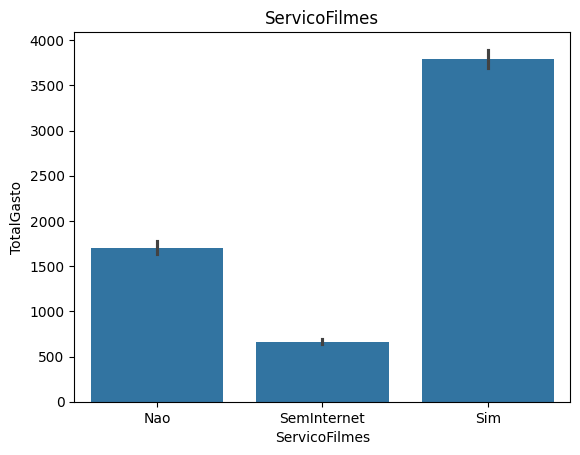




***** TipoContrato *****




,TipoContrato,n(i),f(i),N(i),F(i)
0,Mensal,3269,3269,54.720455,0.915977
1,2 anos,1430,4699,23.937061,0.400687
2,Anual,1275,5974,21.342484,0.357256


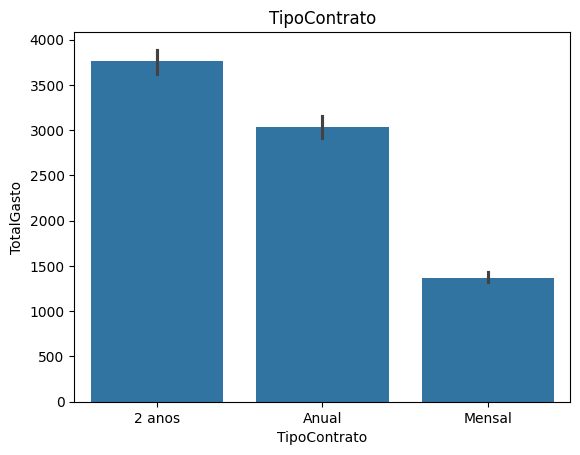




***** FaturaDigital *****




,FaturaDigital,n(i),f(i),N(i),F(i)
0,Sim,3523,3523,58.972213,0.987148
1,Nao,2451,5974,41.027787,0.686772


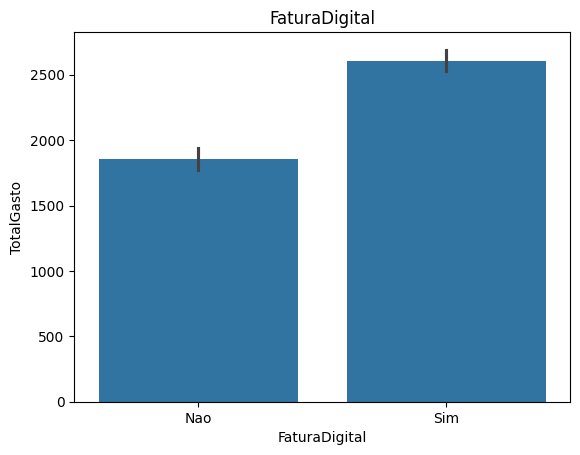




***** FormaPagamento *****




,FormaPagamento,n(i),f(i),N(i),F(i)
0,BoletoEletronico,2006,2006,33.578842,0.562083
1,BoletoImpresso,1361,3367,22.782056,0.381353
2,DebitoAutomatico,1305,4672,21.844660,0.365662
3,CartaoCredito,1302,5974,21.794443,0.364822


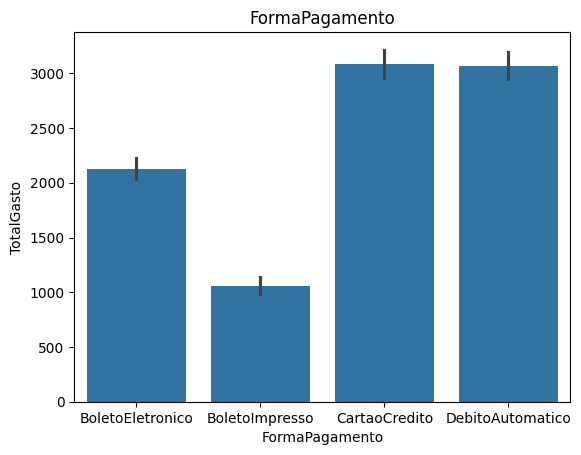




***** Churn *****




,Churn,n(i),f(i),N(i),F(i)
0,Nao,4387,4387,73.434884,1.229241
1,Sim,1587,5974,26.565116,0.444679


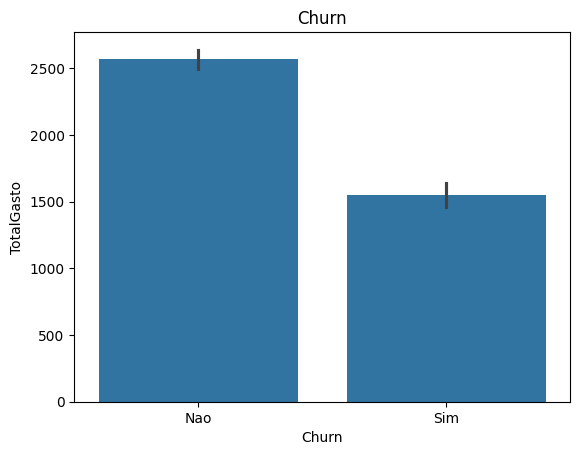

In [20]:
for col in df.columns:
  if col not in ['IDCliente', 'MesesComoCliente', 'ValorMensal', 'TotalGasto']:
    print('\n\n')
    print(f'***** {col} *****')
    print('\n')
    fp = df[col].value_counts().reset_index()
    fp.columns = [col, 'n(i)']
    fp['f(i)'] = fp['n(i)'].cumsum()
    fp['N(i)'] = fp['n(i)'] / fp['n(i)'].sum() * 100
    fp['F(i)'] = fp['N(i)'] / fp['n(i)'].sum() * 100
    display(fp)
    sns.barplot(data=df, x=col, y='TotalGasto')
    plt.title(col)
    plt.show()